# Preliminary analysis (Sentiment vs Key variables).ipynb (JT)

# Load and explore the data

<div class="alert alert-block alert-info">
Notebook Start

In [1]:
# Import necessary libraries.
# Creating the linear regression
import numpy as np
import pandas as pd
import pylab as py
import sklearn

# Visualise the linear regression.
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scipy
from scipy import stats
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.graphics.gofplots import qqplot

# Import the statsmodels.
import statsmodels.api as sm 
from statsmodels.formula.api import ols

In [2]:
# Load the CSV file(s) as reviews.
variables = pd.read_csv('variables.csv')  

# Print the DataFrame.
variables.head() 

,Month / Year,Average Compound,Average Polarity,Average Subjectivity,Average lm_score,EOM,VALUES,VLOOKUP,check,UK Core inflation (%),UK Unemployment (%),UK Average Weekly earnings growth (%),UK GDP growth (%),UK benchmark rate (%),UK Economic Inactivity rate (%),UK house price index mom (%)
0,Sep-98,0.992500,0.083288,0.435206,-0.212121,Sep-98,Sep-98,Sep-98,True,1.3,6.2,NaN,0.1,7.50,23.6,0.3
1,Oct-98,0.999150,0.084071,0.381859,-0.163729,Oct-98,Oct-98,Oct-98,True,1.2,6.2,NaN,0.5,7.50,23.6,1.0
2,Nov-98,0.998033,0.081633,0.429144,-0.316236,Nov-98,Nov-98,Nov-98,True,1.1,6.1,NaN,0.2,7.25,23.5,-0.1
3,Dec-98,0.999400,0.079172,0.411767,-0.348099,Dec-98,Dec-98,Dec-98,True,1.2,6.2,NaN,0.3,6.75,23.5,-0.2
4,Jan-99,0.997600,0.086975,0.395355,-0.266017,Jan-99,Jan-99,Jan-99,True,1.2,6.2,NaN,0.2,6.25,23.3,0.7


In [3]:
# Replace the missing values with 0 (if applicable)
variables.fillna(0, inplace=True)

In [4]:
# Print the DataFrame.
variables.head() 

,Month / Year,Average Compound,Average Polarity,Average Subjectivity,Average lm_score,EOM,VALUES,VLOOKUP,check,UK Core inflation (%),UK Unemployment (%),UK Average Weekly earnings growth (%),UK GDP growth (%),UK benchmark rate (%),UK Economic Inactivity rate (%),UK house price index mom (%)
0,Sep-98,0.992500,0.083288,0.435206,-0.212121,Sep-98,Sep-98,Sep-98,True,1.3,6.2,0.0,0.1,7.50,23.6,0.3
1,Oct-98,0.999150,0.084071,0.381859,-0.163729,Oct-98,Oct-98,Oct-98,True,1.2,6.2,0.0,0.5,7.50,23.6,1.0
2,Nov-98,0.998033,0.081633,0.429144,-0.316236,Nov-98,Nov-98,Nov-98,True,1.1,6.1,0.0,0.2,7.25,23.5,-0.1
3,Dec-98,0.999400,0.079172,0.411767,-0.348099,Dec-98,Dec-98,Dec-98,True,1.2,6.2,0.0,0.3,6.75,23.5,-0.2
4,Jan-99,0.997600,0.086975,0.395355,-0.266017,Jan-99,Jan-99,Jan-99,True,1.2,6.2,0.0,0.2,6.25,23.3,0.7


In [5]:
# Determine the number of missing values.
variables.isna().sum()

Month / Year                             0
Average Compound                         0
Average Polarity                         0
Average Subjectivity                     0
Average lm_score                         0
EOM                                      0
VALUES                                   0
VLOOKUP                                  0
check                                    0
UK Core inflation (%)                    0
UK Unemployment (%)                      0
UK Average Weekly earnings growth (%)    0
UK GDP growth (%)                        0
UK benchmark rate (%)                    0
UK Economic Inactivity rate (%)          0
UK house price index mom (%)             0
dtype: int64

In [6]:
# View the metadata.
variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Month / Year                           272 non-null    object 
 1   Average Compound                       272 non-null    float64
 2   Average Polarity                       272 non-null    float64
 3   Average Subjectivity                   272 non-null    float64
 4   Average lm_score                       272 non-null    float64
 5   EOM                                    272 non-null    object 
 6   VALUES                                 272 non-null    object 
 7   VLOOKUP                                272 non-null    object 
 8   check                                  272 non-null    object 
 9   UK Core inflation (%)                  272 non-null    float64
 10  UK Unemployment (%)                    272 non-null    float64
 11  UK Ave

In [7]:
# Basic descriptive statistics.
variables.describe()

,Average Compound,Average Polarity,Average Subjectivity,Average lm_score,UK Core inflation (%),UK Unemployment (%),UK Average Weekly earnings growth (%),UK GDP growth (%),UK benchmark rate (%),UK Economic Inactivity rate (%),UK house price index mom (%)
count,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000
mean,0.759256,0.094863,0.413387,-0.175729,1.797059,5.605147,2.722426,0.148162,2.299265,22.495956,0.497426
std,0.382848,0.016664,0.020909,0.165373,1.061534,1.378181,1.928896,1.584145,2.260670,1.618557,0.801171
min,-0.999300,0.041209,0.324390,-0.654952,-0.100000,0.000000,-2.900000,-19.200000,0.000000,0.000000,-2.500000
25%,0.603565,0.084715,0.402782,-0.276640,1.200000,4.700000,1.300000,-0.100000,0.500000,21.800000,0.000000
50%,0.995075,0.093557,0.414254,-0.191604,1.600000,5.200000,2.700000,0.200000,0.750000,22.900000,0.500000
75%,0.999243,0.103759,0.425500,-0.081818,2.100000,6.200000,4.200000,0.500000,4.562500,23.300000,1.000000
max,0.999900,0.161252,0.484238,0.321495,6.500000,8.500000,8.900000,9.300000,7.500000,23.600000,2.800000


# Remove & rename columns

In [8]:
# Drop unnecessary columns

variables.drop(columns=['Average Compound', 'Average Polarity', 'Average Subjectivity', 'EOM', 'VALUES', 'VLOOKUP', 'check'], 
               inplace=True)

# Rename the column headers

variables.rename(columns={
    'Average lm_score': 'Sentiment_LM',
    'UK Core inflation (%)' : 'Inflation_Core',
    'UK Unemployment (%)': 'Unemployment',
    'UK Average Weekly earnings growth (%)' : 'Wages_growth',
    'UK GDP growth (%)' : 'GDP_growth',
    'UK benchmark rate (%)' : 'Benchmark_rate',
    'UK Economic Inactivity rate (%)' : 'Economic_Inactivity_rate',
    'UK house price index mom (%)' : 'House_price_index'
}, inplace=True)

# View column names
variables.columns

Index(['Month / Year', 'Sentiment_LM', 'Inflation_Core', 'Unemployment',
       'Wages_growth', 'GDP_growth', 'Benchmark_rate',
       'Economic_Inactivity_rate', 'House_price_index'],
      dtype='object')

In [9]:
# View the dataframe
variables.head()

,Month / Year,Sentiment_LM,Inflation_Core,Unemployment,Wages_growth,GDP_growth,Benchmark_rate,Economic_Inactivity_rate,House_price_index
0,Sep-98,-0.212121,1.3,6.2,0.0,0.1,7.50,23.6,0.3
1,Oct-98,-0.163729,1.2,6.2,0.0,0.5,7.50,23.6,1.0
2,Nov-98,-0.316236,1.1,6.1,0.0,0.2,7.25,23.5,-0.1
3,Dec-98,-0.348099,1.2,6.2,0.0,0.3,6.75,23.5,-0.2
4,Jan-99,-0.266017,1.2,6.2,0.0,0.2,6.25,23.3,0.7


# Save the DataFrame as a CSV file

In [10]:
# Create a CSV file as output.
variables.to_csv('variables_clean.csv', index=False)

In [11]:
# Import new CSV file with Pandas.
variables_clean = pd.read_csv('variables_clean.csv')

# View DataFrame.
variables_clean.head() 

,Month / Year,Sentiment_LM,Inflation_Core,Unemployment,Wages_growth,GDP_growth,Benchmark_rate,Economic_Inactivity_rate,House_price_index
0,Sep-98,-0.212121,1.3,6.2,0.0,0.1,7.50,23.6,0.3
1,Oct-98,-0.163729,1.2,6.2,0.0,0.5,7.50,23.6,1.0
2,Nov-98,-0.316236,1.1,6.1,0.0,0.2,7.25,23.5,-0.1
3,Dec-98,-0.348099,1.2,6.2,0.0,0.3,6.75,23.5,-0.2
4,Jan-99,-0.266017,1.2,6.2,0.0,0.2,6.25,23.3,0.7


In [12]:
# Check metadata
variables_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month / Year              272 non-null    object 
 1   Sentiment_LM              272 non-null    float64
 2   Inflation_Core            272 non-null    float64
 3   Unemployment              272 non-null    float64
 4   Wages_growth              272 non-null    float64
 5   GDP_growth                272 non-null    float64
 6   Benchmark_rate            272 non-null    float64
 7   Economic_Inactivity_rate  272 non-null    float64
 8   House_price_index         272 non-null    float64
dtypes: float64(8), object(1)
memory usage: 19.2+ KB


In [13]:
# Check shape
variables_clean.shape

(272, 9)

### Determine Correlation 

In [14]:
# Determine correlation
variables_clean.corr()

,Sentiment_LM,Inflation_Core,Unemployment,Wages_growth,GDP_growth,Benchmark_rate,Economic_Inactivity_rate,House_price_index
Sentiment_LM,1.000000,-0.229423,-0.353744,0.116285,-0.047610,0.184597,-0.055428,0.142878
Inflation_Core,-0.229423,1.000000,0.106526,0.309099,-0.007420,-0.454871,-0.013902,-0.178638
Unemployment,-0.353744,0.106526,1.000000,-0.431224,0.014675,-0.147660,0.478248,-0.149473
Wages_growth,0.116285,0.309099,-0.431224,1.000000,-0.024000,0.126611,0.030629,0.061977
GDP_growth,-0.047610,-0.007420,0.014675,-0.024000,1.000000,0.001329,0.020642,0.120786
Benchmark_rate,0.184597,-0.454871,-0.147660,0.126611,0.001329,1.000000,0.390476,0.159392
Economic_Inactivity_rate,-0.055428,-0.013902,0.478248,0.030629,0.020642,0.390476,1.000000,0.097568
House_price_index,0.142878,-0.178638,-0.149473,0.061977,0.120786,0.159392,0.097568,1.000000


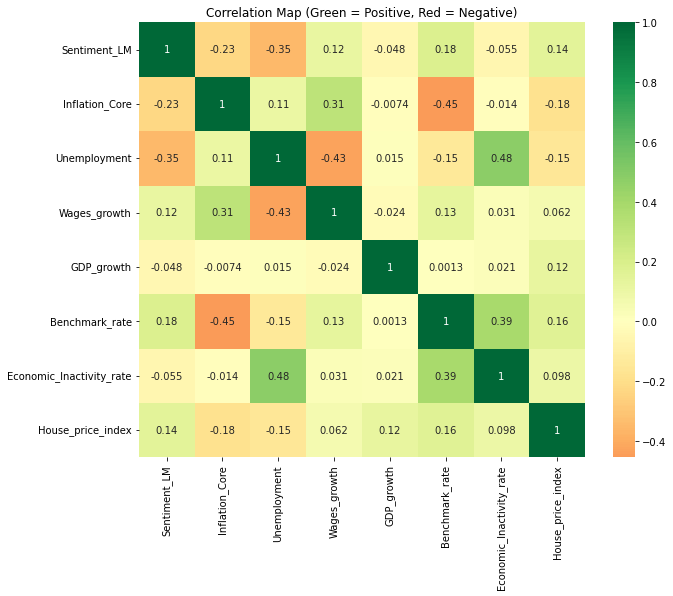

In [15]:
# Determine correlation
corr = variables_clean.corr()

# Create the correlation heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Map (Green = Positive, Red = Negative)')
plt.show()

## Sentiment vs Inflation

In [16]:
# Define the dependent variable.
y = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x = variables_clean['Inflation_Core'] 


C:\Users\Jai T\AppData\Local\Temp\ipykernel_11304\2397996783.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables_clean,


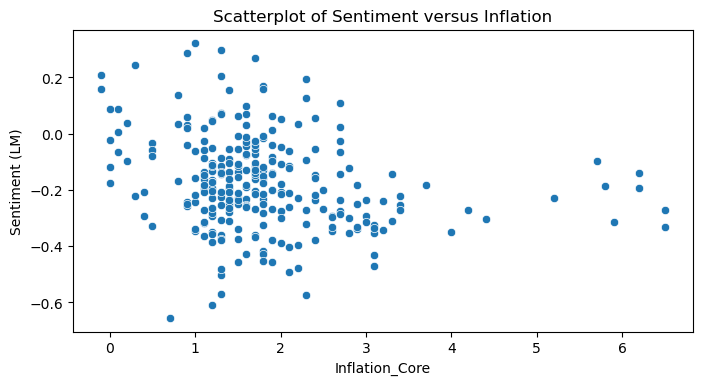

In [17]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Inflation")
plt.xlabel("Inflation_Core")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Inflation_Core",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [18]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Inflation_Core'], deg = 1)

# View output.
reg

array([-1.47267496,  1.53826707])

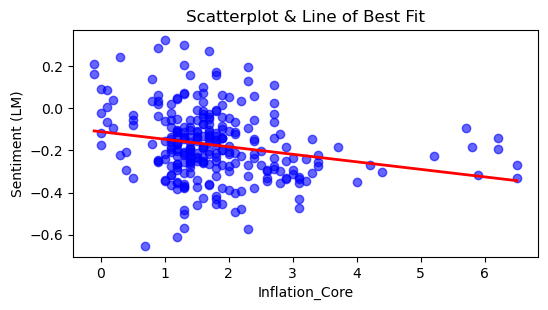

In [20]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend = np.polyval(reg, variables_clean['Inflation_Core'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Inflation_Core',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Inflation_Core")
plt.ylabel("Sentiment (LM)")
plt.show()

In [21]:
# Pass linear regression through OLS methods.
test = ols('y ~ x', data = variables_clean).fit()

# Print the regression table.
test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     15.00
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           0.000135
Time:                        01:14:21   Log-Likelihood:                 111.38
No. Observations:                 272   AIC:                            -218.8
Df Residuals:                     270   BIC:                            -211.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1115      0.019     -5.792      0.000      -0.149      -0.074
x             -0.0357      0.009     -3.873      0.000      -0.054      -0.018
==============================================================================
Omnibus:                        4.862   Durbin-Watson:                   1.501
Prob(Omnibus):                  0.088   Jarque-Bera (JB):                5.343
Skew:                           0.180   Prob(JB):                       0.0691
Kurtosis:                       3.584   Cond. No.                         4.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Unemployment

In [22]:
# Define the dependent variable.
y2 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x2 = variables_clean['Unemployment'] 


C:\Users\Jai T\AppData\Local\Temp\ipykernel_11304\160067645.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables_clean,


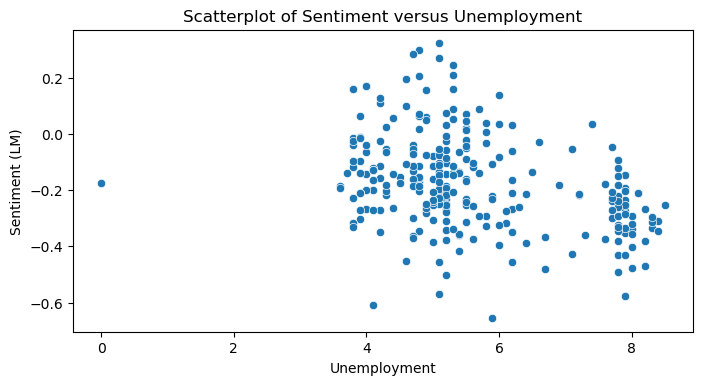

In [24]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Unemployment",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [26]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg2 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Unemployment'], deg = 1)

# View output.
reg2

array([-2.94801833,  5.08709464])

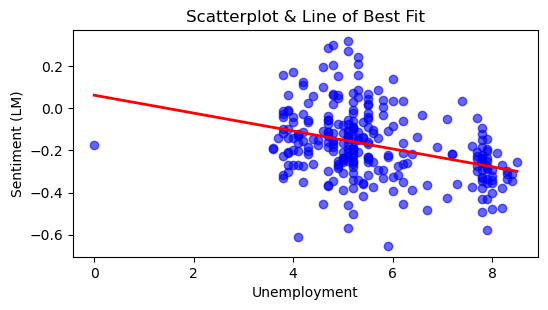

In [28]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend2 = np.polyval(reg2, variables_clean['Unemployment'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Unemployment',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Unemployment")
plt.ylabel("Sentiment (LM)")
plt.show()

In [27]:
# Pass linear regression through OLS methods.
test2 = ols('y2 ~ x2', data = variables_clean).fit()

# Print the regression table.
test2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y2   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     38.62
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           1.94e-09
Time:                        01:28:50   Log-Likelihood:                 122.21
No. Observations:                 272   AIC:                            -240.4
Df Residuals:                     270   BIC:                            -233.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0622      0.039      1.578      0.116      -0.015       0.140
x2            -0.0424      0.007     -6.214      0.000      -0.056      -0.029
==============================================================================
Omnibus:                        7.645   Durbin-Watson:                   1.616
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                9.393
Skew:                           0.243   Prob(JB):                      0.00913
Kurtosis:                       3.769   Cond. No.                         24.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Wages Growth

In [29]:
# Define the dependent variable.
y3 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x3 = variables_clean['Wages_growth']

C:\Users\Jai T\AppData\Local\Temp\ipykernel_11304\1253790309.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables_clean,


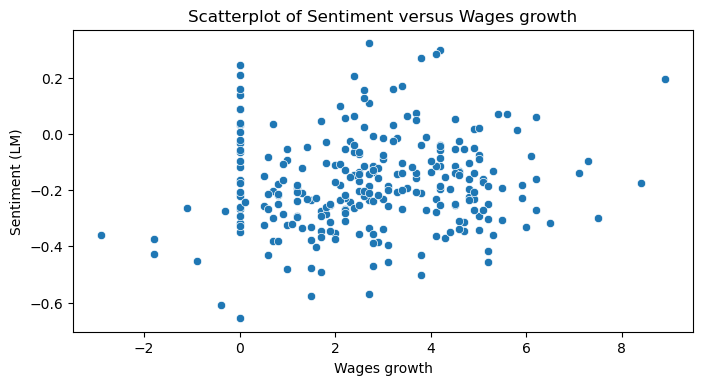

In [31]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Wages growth")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Wages_growth",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [32]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg3 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Wages_growth'], deg = 1)

# View output.
reg3

array([1.3563323 , 2.96077344])

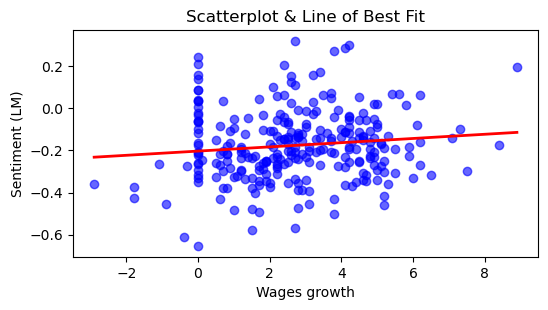

In [33]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend3 = np.polyval(reg3, variables_clean['Wages_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Wages_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [34]:
# Pass linear regression through OLS methods.
test3 = ols('y3 ~ x3', data = variables_clean).fit()

# Print the regression table.
test3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y3   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.701
Date:                Sat, 08 Nov 2025   Prob (F-statistic):             0.0554
Time:                        01:39:03   Log-Likelihood:                 105.88
No. Observations:                 272   AIC:                            -207.8
Df Residuals:                     270   BIC:                            -200.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2029      0.017    -11.740      0.000      -0.237      -0.169
x3             0.0100      0.005      1.924      0.055      -0.000       0.020
==============================================================================
Omnibus:                        8.717   Durbin-Watson:                   1.432
Prob(Omnibus):                  0.013   Jarque-Bera (JB):                8.780
Skew:                           0.379   Prob(JB):                       0.0124
Kurtosis:                       3.447   Cond. No.                         6.13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs GDP Growth

In [35]:
# Define the dependent variable.
y4 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x4 = variables_clean['GDP_growth']

C:\Users\Jai T\AppData\Local\Temp\ipykernel_11304\1786563433.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables_clean,


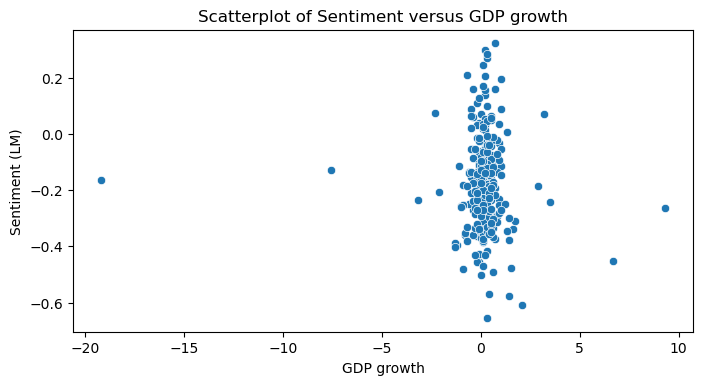

In [36]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus GDP growth")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "GDP_growth",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [37]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg4 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['GDP_growth'], deg = 1)

# View output.
reg4

array([-0.45606918,  0.06801717])

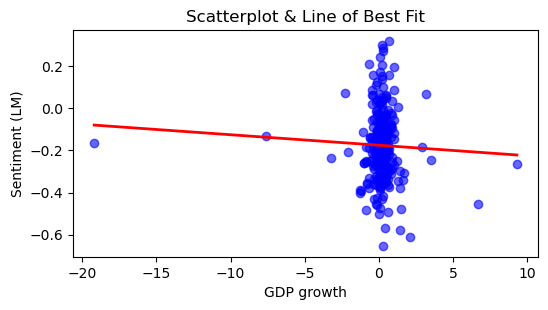

In [38]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend4 = np.polyval(reg4, variables_clean['GDP_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables_clean,
    x='GDP_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [39]:
# Pass linear regression through OLS methods.
test4 = ols('y4 ~ x4', data = variables_clean).fit()

# Print the regression table.
test4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y4   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6134
Date:                Sat, 08 Nov 2025   Prob (F-statistic):              0.434
Time:                        02:00:16   Log-Likelihood:                 104.34
No. Observations:                 272   AIC:                            -204.7
Df Residuals:                     270   BIC:                            -197.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1750      0.010    -17.363      0.000      -0.195      -0.155
x4            -0.0050      0.006     -0.783      0.434      -0.017       0.008
==============================================================================
Omnibus:                        7.571   Durbin-Watson:                   1.413
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                7.609
Skew:                           0.337   Prob(JB):                       0.0223
Kurtosis:                       3.465   Cond. No.                         1.60
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Benchmark rate

In [40]:
# Define the dependent variable.
y5 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x5 = variables_clean['Benchmark_rate']

C:\Users\Jai T\AppData\Local\Temp\ipykernel_11304\686704817.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables_clean,


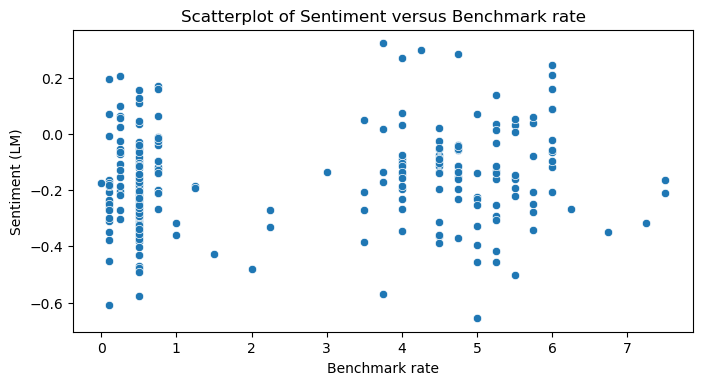

In [41]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Benchmark rate")
plt.xlabel("Benchmark rate")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Benchmark_rate",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [42]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg5 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Benchmark_rate'], deg = 1)

# View output.
reg5

array([2.52346774, 2.74271126])

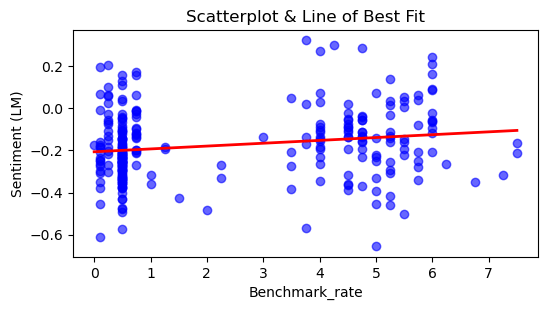

In [43]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend5 = np.polyval(reg5, variables_clean['Benchmark_rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Benchmark_rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Benchmark_rate")
plt.ylabel("Sentiment (LM)")
plt.show()

In [44]:
# Pass linear regression through OLS methods.
test5 = ols('y5 ~ x5', data = variables_clean).fit()

# Print the regression table.
test5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y5   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     9.525
Date:                Sat, 08 Nov 2025   Prob (F-statistic):            0.00224
Time:                        02:07:51   Log-Likelihood:                 108.74
No. Observations:                 272   AIC:                            -213.5
Df Residuals:                     270   BIC:                            -206.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2068      0.014    -14.670      0.000      -0.235      -0.179
x5             0.0135      0.004      3.086      0.002       0.005       0.022
==============================================================================
Omnibus:                        6.066   Durbin-Watson:                   1.468
Prob(Omnibus):                  0.048   Jarque-Bera (JB):                6.506
Skew:                           0.245   Prob(JB):                       0.0387
Kurtosis:                       3.579   Cond. No.                         4.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Economic Inactivity rate

In [45]:
# Define the dependent variable.
y6 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x6 = variables_clean['Economic_Inactivity_rate']

C:\Users\Jai T\AppData\Local\Temp\ipykernel_11304\1907082039.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables_clean,


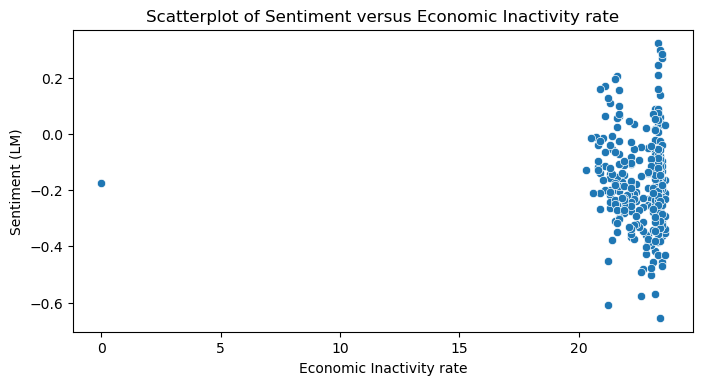

In [46]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Economic Inactivity rate")
plt.xlabel("Economic Inactivity rate")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Economic_Inactivity_rate",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [47]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg6 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Economic_Inactivity_rate'], deg = 1)

# View output.
reg6

array([-0.54249001, 22.40062463])

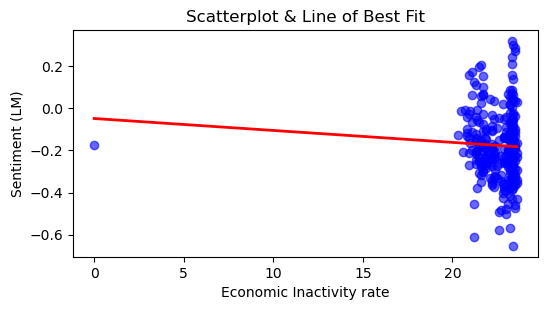

In [48]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend6 = np.polyval(reg6, variables_clean['Economic_Inactivity_rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Economic_Inactivity_rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Economic Inactivity rate")
plt.ylabel("Sentiment (LM)")
plt.show()

In [49]:
# Pass linear regression through OLS methods.
test6 = ols('y6 ~ x6', data = variables_clean).fit()

# Print the regression table.
test6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y6   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8321
Date:                Sat, 08 Nov 2025   Prob (F-statistic):              0.362
Time:                        02:16:32   Log-Likelihood:                 104.45
No. Observations:                 272   AIC:                            -204.9
Df Residuals:                     270   BIC:                            -197.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0483      0.140     -0.345      0.730      -0.324       0.227
x6            -0.0057      0.006     -0.912      0.362      -0.018       0.007
==============================================================================
Omnibus:                        7.947   Durbin-Watson:                   1.421
Prob(Omnibus):                  0.019   Jarque-Bera (JB):                8.110
Skew:                           0.341   Prob(JB):                       0.0173
Kurtosis:                       3.500   Cond. No.                         315.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs House Price index

In [50]:
# Define the dependent variable.
y7 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x7 = variables_clean['House_price_index']

C:\Users\Jai T\AppData\Local\Temp\ipykernel_11304\3669147160.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables_clean,


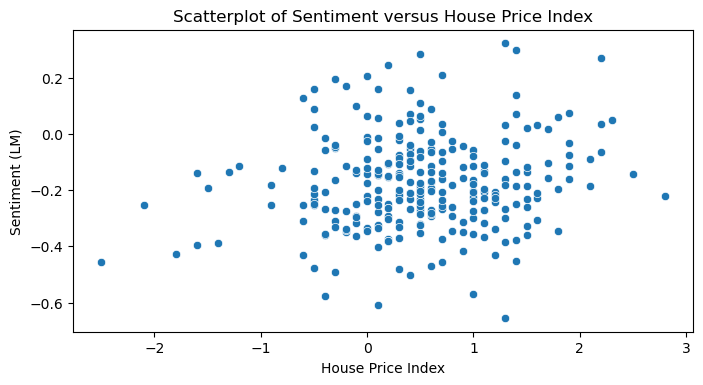

In [51]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus House Price Index")
plt.xlabel("House Price Index")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "House_price_index",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [52]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg7 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['House_price_index'], deg = 1)

# View output.
reg7

array([0.69219042, 0.61906443])

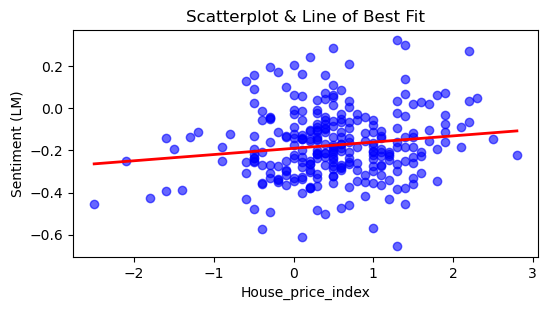

In [53]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend7 = np.polyval(reg7, variables_clean['House_price_index'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables_clean,
    x='House_price_index',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("House_price_index")
plt.ylabel("Sentiment (LM)")
plt.show()

In [54]:
# Pass linear regression through OLS methods.
test7 = ols('y7 ~ x7', data = variables_clean).fit()

# Print the regression table.
test7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y7   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     5.627
Date:                Sat, 08 Nov 2025   Prob (F-statistic):             0.0184
Time:                        02:22:08   Log-Likelihood:                 106.83
No. Observations:                 272   AIC:                            -209.7
Df Residuals:                     270   BIC:                            -202.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1904      0.012    -16.261      0.000      -0.213      -0.167
x7             0.0295      0.012      2.372      0.018       0.005       0.054
==============================================================================
Omnibus:                        7.703   Durbin-Watson:                   1.501
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                7.869
Skew:                           0.332   Prob(JB):                       0.0196
Kurtosis:                       3.504   Cond. No.                         1.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<div class="alert alert-block alert-info">
Notebook End